# GSMo-CNN (Generalised Stacking Multi-output CNN) — minimal Plant Village demonstration

Reproduces a **scaled-down demonstration** of: Yao, Tran, Garg & Sawyer, *Deep Learning for Plant Identification and Disease Classification from Leaf Images: Multi-prediction Approaches*, ACM Computing Surveys 56(6), 2024 (DOI [10.1145/3639816](https://doi.org/10.1145/3639816); [arXiv:2310.16273v1](https://arxiv.org/abs/2310.16273)).

**Author code:** https://github.com/funzi-son/AI4Plant @ commit `b5cee5b95fe2c3120b7bf0b31bc17473882c9212` (no license file is present in the repository; reuse terms should be verified before any redistribution).

**Scope of this notebook (English / 日本語)**
- We train the authors' **GSMo-CNN** architecture — a stacked multi-output CNN with four softmax heads and cross-connected second prediction layers — with their **custom 4-conv CNN backbone** on a **small subsample of the Plant Village dataset** (a few class folders only), for a few epochs, one run.
- 論文のGSMo-CNN（4つのソフトマックス出力と交差接続された第2予測層を持つスタック型マルチ出力CNN）を、著者独自の小型CNNバックボーンで、Plant Villageデータセットのごく一部（数クラス・少数エポック・1回の実行）で学習・評価する**縮小デモ**です。
- This is **NOT** the paper's full benchmark (54,305 images, 10 repeated runs, early stopping with patience 50). It demonstrates the method, data format and metrics, not the published accuracy numbers (e.g. 99.466% disease accuracy on full Plant Village).
- これは論文の完全なベンチマーク（54,305画像・10回反復）ではなく、手法・データ形式・評価指標のデモです。論文の精度数値自体は再現しません。

**Runtime:** GPU (T4) is recommended; the small subsample also runs on CPU. Select *Runtime > Change runtime type* accordingly. GPU（T4）推奨。小型サブサンプルはCPUでも動作します。

## 1. Environment check

**Expected result:** TensorFlow version and the list of available devices (CPU and/or GPU). TensorFlow is preinstalled on Colab; if a GPU runtime was selected, a GPU entry appears here.
**期待される結果:** TensorFlowのバージョンと利用可能なデバイス一覧。GPUランタイムを選択していればGPUが表示されます。

In [ ]:
import tensorflow as tf, sys
print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))
gpus = tf.config.list_physical_devices('GPU')
print("Device used for training:", "GPU" if gpus else "CPU (small subsample is still feasible)")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Device used for training: GPU


## 2. Download the Plant Village archive (inside Colab only)

**Input:** `Plant_leaf_diseases_dataset_without_augmentation.zip` (868,032,562 bytes; sha256 `ac343245...49b90ff0`) from the Mendeley record [tywbtsjrjv v1](https://data.mendeley.com/datasets/tywbtsjrjv/1) — the exact Plant Village archive the authors' README instructs to use.
**Expected result:** the zip downloaded to `/content` and its SHA-256 verified against the Mendeley record metadata (retrieved from the record API on the host, metadata only). This is the only large download (~0.9 GB).
**期待される結果:** MendeleyレコードのZIPを `/content` にダウンロードし、レコード記載のSHA-256と照合します（約0.9 GB、本ノートブック唯一の大きなダウンロード）。

In [ ]:
import urllib.request, hashlib, os, time

URL = "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/d5652a28-c1d8-4b76-97f3-72fb80f94efc/file_downloaded"
ZIP = "/content/Plant_leaf_diseases_dataset_without_augmentation.zip"
EXPECTED_SHA256 = "ac3432453984d02a86197987e775a5429d0d59e7cc7c35bcf5a8f50349b90ff0"
EXPECTED_SIZE = 868032562

# Mendeley's download endpoint requires a browser-like User-Agent
req = urllib.request.Request(URL, headers={"User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 Chrome/120 Safari/537.36"})
t0 = time.time()
h, n = hashlib.sha256(), 0
with urllib.request.urlopen(req) as r, open(ZIP, "wb") as f:
    assert r.status == 200 and int(r.headers.get("Content-Length", -1)) == EXPECTED_SIZE
    while True:
        chunk = r.read(1 << 22)
        if not chunk:
            break
        h.update(chunk); n += len(chunk)
        f.write(chunk)
        if n // (1 << 26) != (n - len(chunk)) // (1 << 26):
            print(f"  {n/1e6:.0f} MB ...", flush=True)
digest, size = h.hexdigest(), os.path.getsize(ZIP)
print(f"downloaded {size} bytes in {time.time()-t0:.0f}s")
print("sha256:", digest)
assert digest == EXPECTED_SHA256 and size == EXPECTED_SIZE, "Archive failed checksum verification!"
print("Archive verified against Mendeley record metadata.")

  67 MB ...


  134 MB ...


  201 MB ...


  268 MB ...


  336 MB ...


...

  604 MB ...


  671 MB ...


  738 MB ...


  805 MB ...


downloaded 868032562 bytes in 38s
sha256: ac3432453984d02a86197987e775a5429d0d59e7cc7c35bcf5a8f50349b90ff0
Archive verified against Mendeley record metadata.


## 3. Selective extraction of a few classes

**Input:** the verified zip. We extract **only** the members of a small, fixed set of class folders (2 plant species × 3 conditions) — and only the first `PER_CLASS=200` images per class that the demo uses — as recommended by the authors' README (removing `Background_without_leaves`, `Plant___Disease` folder naming with a triple underscore).
**Expected result:** `/content/plant_village/Plant_leave_diseases_dataset_without_augmentation/<CLASS>` folders with 200 images each; all other classes stay inside the zip, untouched.
**期待される結果:** ZIPからデモで使う数クラス・各クラス200枚のみ展開します。他のクラスはZIP内にそのまま残ります。

In [ ]:
import zipfile, os

CLASSES = [
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___healthy",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___healthy",
]
ROOT_IN_ZIP = "Plant_leave_diseases_dataset_without_augmentation"
DEST = "/content/plant_village"
PER_CLASS = 200  # demo subsample cap (matches the loading cell)

with zipfile.ZipFile(ZIP) as z:
    names = z.namelist()
    for c in CLASSES:
        wanted = sorted(n for n in names
                        if n.startswith(f"{ROOT_IN_ZIP}/{c}/") and not n.endswith("/"))[:PER_CLASS]
        assert len(wanted) == PER_CLASS, (c, len(wanted))
        for n in wanted:
            target = os.path.join(DEST, n)  # n already starts with ROOT_IN_ZIP
            os.makedirs(os.path.dirname(target), exist_ok=True)
            with z.open(n) as src, open(target, "wb") as out:
                out.write(src.read())
        print(f"extracted {c}: {len(os.listdir(os.path.join(DEST, ROOT_IN_ZIP, c)))} files", flush=True)

assert all(os.path.isdir(os.path.join(DEST, ROOT_IN_ZIP, c)) for c in CLASSES)

extracted Apple___Apple_scab: 200 files


extracted Apple___Black_rot: 200 files


extracted Apple___healthy: 200 files


extracted Tomato___Late_blight: 200 files


extracted Tomato___Leaf_Mold: 200 files


extracted Tomato___healthy: 200 files


## 4. Load images and build labels (author's convention)

**Input:** the extracted class folders. Following `load_data.py` / `Leaf_disease_main.py` (commit `b5cee5b`), each folder name `Plant___Disease` (triple underscore) yields a plant label and a disease label; images are BGR via OpenCV, resized to 256×256 (`fig_size=256`).
**Expected result:** arrays `X` (N, 256, 256, 3) with per-image plant and disease label strings, plus a short class table. To keep the demo small we cap the images per class (`PER_CLASS=200`); the full paper uses every image of all 38 classes.
**期待される結果:** 著者コードと同じ規則（`植物___病害`）でラベルを解析し、256×256にリサイズした画像配列とクラス一覧を表示します（デモ用にクラスごと200枚に制限）。

In [ ]:
import cv2, numpy as np, os

FIG_SIZE = 256   # author's fig_size
PER_CLASS = 200  # demo subsample cap (paper uses all images)
BASE = f"/content/plant_village/{ROOT_IN_ZIP}"

X, plant_names, disease_names = [], [], []
for c in CLASSES:
    plant, disease = c.split("___")           # author's triple-underscore convention
    files = sorted(os.listdir(os.path.join(BASE, c)))[:PER_CLASS]
    for fn in files:
        img = cv2.imread(os.path.join(BASE, c, fn))
        X.append(cv2.resize(img, (FIG_SIZE, FIG_SIZE)))
        plant_names.append(plant)
        disease_names.append(disease)

X = np.array(X, dtype=np.uint8).reshape(-1, FIG_SIZE, FIG_SIZE, 3)
print("X:", X.shape, "| plants:", sorted(set(plant_names)), "| diseases:", sorted(set(disease_names)))
print("images per class:", {c: plant_names.count(c.split('___')[0]) for c in CLASSES})

X: (1200, 256, 256, 3) | plants: ['Apple', 'Tomato'] | diseases: ['Apple_scab', 'Black_rot', 'Late_blight', 'Leaf_Mold', 'healthy']
images per class: {'Apple___Apple_scab': 600, 'Apple___Black_rot': 600, 'Apple___healthy': 600, 'Tomato___Late_blight': 600, 'Tomato___Leaf_Mold': 600, 'Tomato___healthy': 600}


## 5. Input preview

**Expected result:** a 2×3 grid of one real sample image per class, titled `plant / disease`. This previews the actual downloaded inputs (256×256 BGR→RGB) before any modelling; it is not a generated result.
**期待される結果:** クラスごとに実画像を1枚ずつ表示する入力プレビューです。

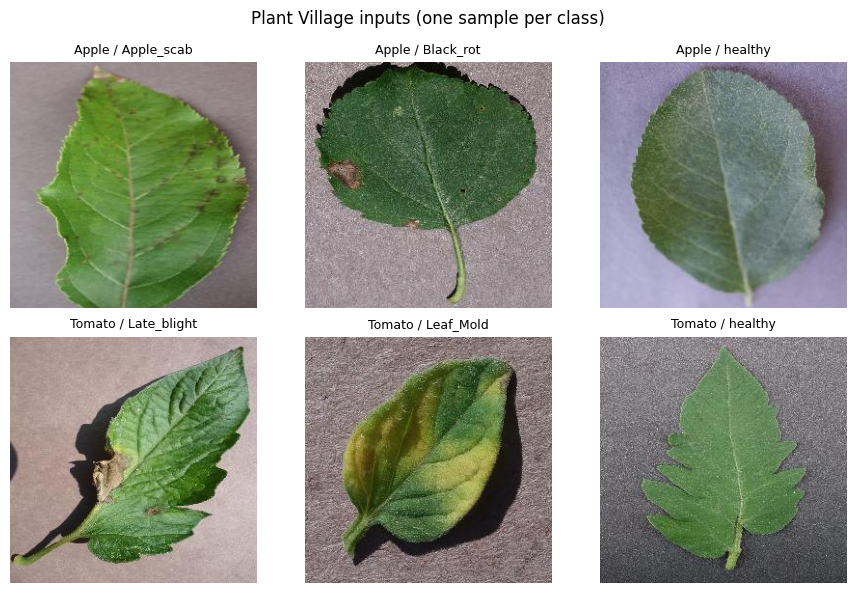

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, c in zip(axes.ravel(), CLASSES):
    plant, disease = c.split("___")
    files = sorted(os.listdir(os.path.join(BASE, c)))
    img = cv2.imread(os.path.join(BASE, c, files[0]))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{plant} / {disease}", fontsize=9)
    ax.axis("off")
fig.suptitle("Plant Village inputs (one sample per class)")
fig.tight_layout()
plt.savefig("/content/inputs_preview.png", dpi=100)
plt.show()

## 6. Encode labels and split (author's protocol)

**Expected result:** one-hot plant and disease matrices via `LabelBinarizer`, and the authors' exact split — `train_test_split(test_size=0.2, random_state=50)` (`Leaf_disease_main.py`). Shapes of the resulting train/test sets are printed.
**期待される結果:** `LabelBinarizer` によるOne-hot化と、著者コードと同一の分割（`test_size=0.2, random_state=50`）を行い、各集合の形状を表示します。

In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

diseaseLB, PlantLB = LabelBinarizer(), LabelBinarizer()
diseaseLabels = diseaseLB.fit_transform(disease_names)
PlantLabels = PlantLB.fit_transform(plant_names)

# sklearn's LabelBinarizer returns a single column for 2 classes; expand so the
# one-hot shape matches the softmax head (author pipeline always has >2 plants)
if PlantLabels.shape[1] == 1:
    PlantLabels = np.hstack([1 - PlantLabels, PlantLabels])
if diseaseLabels.shape[1] == 1:
    diseaseLabels = np.hstack([1 - diseaseLabels, diseaseLabels])

numDis, numPlants = len(diseaseLB.classes_), len(PlantLB.classes_)

(trainX, testX, trainDiseaseY, testDiseaseY,
 trainPlantY, testPlantY) = train_test_split(
    X, diseaseLabels, PlantLabels, test_size=0.2, random_state=50)

print("train:", trainX.shape, "| test:", testX.shape)
print("numPlants:", numPlants, "| numDis:", numDis)

train: (960, 256, 256, 3) | test: (240, 256, 256, 3)
numPlants: 2 | numDis: 5


## 7. Build GSMo-CNN with the authors' custom CNN backbone

**Input:** ported **verbatim** from `train_models.py` (`new_model` and the `new_model` branch of `multi_output_model`) at commit `b5cee5b`. Features go to two temporary softmax heads (`plant_output_t`, `disease_output_t`); each temporary probability is concatenated with the CNN features to form the *other* task's final prediction layer — the paper's "generalised stacking" cross-connection. Loss weights follow the paper's optimum `balance_weight = [0.1, 0.1, 0.4, 0.5]`.
**Expected result:** a compiled Keras model summary with 4 outputs; Adamax optimizer, learning rate 0.001 (author defaults).
**期待される結果:** 著者コードをそのまま移植したGSMo-CNNを構築し、4出力のモデル概要を表示します。損失重みは論文の最適値 `[0.1, 0.1, 0.4, 0.5]`、最適化手法はAdamax（lr=0.001）です。

In [ ]:
from tensorflow.keras import layers, optimizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, MaxPool2D,
                                     Flatten, Dense, concatenate)

def new_model(input_layer):
    # authors' custom 4-conv CNN backbone (train_models.py, verbatim)
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(input_layer)
    x = BatchNormalization(axis=1)(x)
    x = Conv2D(32, (3, 3), padding="same", activation='relu')(x)
    x = BatchNormalization(axis=1)(x)
    x = MaxPool2D(pool_size=(8, 8))(x)
    x = BatchNormalization(axis=1)(x)
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization(axis=1)(x)
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization(axis=1)(x)
    x = MaxPool2D(pool_size=(8, 8))(x)
    x = BatchNormalization(axis=1)(x)
    x = Flatten()(x)
    return x

input_layer = Input(shape=(FIG_SIZE, FIG_SIZE, 3))
x = new_model(input_layer)

# authors' GSMo-CNN ("new_model") heads: temporary predictions cross-connected
output_plant_t = Dense(numPlants, "softmax", name="plant_output_t")(x)
output_dis_t = Dense(numDis, "softmax", name="disease_output_t")(x)
d_plant = concatenate([x, output_plant_t])
d_dis = concatenate([x, output_dis_t])
output_plant = Dense(numPlants, "softmax", name="plant_output")(d_dis)
output_dis = Dense(numDis, "softmax", name="disease_output")(d_plant)

model = Model(inputs=input_layer,
              outputs=[output_plant, output_dis, output_plant_t, output_dis_t])

balance_weight = [0.1, 0.1, 0.4, 0.5]   # paper's grid-searched optimum
lossWeights = {"plant_output": balance_weight[2], "disease_output": balance_weight[3],
               "plant_output_t": balance_weight[0], "disease_output_t": balance_weight[1]}
model.compile(optimizer=optimizers.Adamax(learning_rate=0.001),
              loss={k: "categorical_crossentropy" for k in lossWeights},
              loss_weights=lossWeights,
              # TF 2.20 needs one metrics entry per output (author code: metrics=["accuracy"])
              metrics={k: ["accuracy"] for k in lossWeights})
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │      1,024 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │      1,024 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 4, 4, 32)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4, 32)  │         16 │ max_pooling2d_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disease_output_t    │ (None, 5)         │      2,565 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ plant_output_t      │ (None, 2)         │      1,026 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 517)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ disease_output_t

 Total params: 38,290 (149.57 KB)

 Trainable params: 37,066 (144.79 KB)

 Non-trainable params: 1,224 (4.78 KB)

## 8. Train (demonstration schedule)

**Expected result:** training history for the 4 losses. Author settings kept where feasible: Adamax lr 0.001, batch size 16, 80/20 split with 10% of training as validation. **Adapted for the demo:** only 6 epochs (paper: up to 10000 with early stopping, patience 50) so the notebook finishes quickly; this limits achievable accuracy.
**期待される結果:** 4つの損失の学習履歴を表示します。Adamax・バッチ16・検証10%は著者の設定、エポック数のみデモ用に6に短縮しています（論文はearly stopping patience 50）。

In [ ]:
history = model.fit(trainX,
                    {"plant_output": trainPlantY, "disease_output": trainDiseaseY,
                     "plant_output_t": trainPlantY, "disease_output_t": trainDiseaseY},
                    batch_size=16, epochs=6, validation_split=0.1, shuffle=True, verbose=2)
final_loss = {k: float(v[-1]) for k, v in history.history.items() if k.endswith("loss")}
print(final_loss)

Epoch 1/6


54/54 - 19s - 352ms/step - disease_output_accuracy: 0.3704 - disease_output_loss: 1.4724 - disease_output_t_accuracy: 0.3380 - disease_output_t_loss: 1.5071 - loss: 1.2254 - plant_output_accuracy: 0.6227 - plant_output_loss: 0.6591 - plant_output_t_accuracy: 0.5359 - plant_output_t_loss: 0.7489 - val_disease_output_accuracy: 0.1458 - val_disease_output_loss: 2.8886 - val_disease_output_t_accuracy: 0.1562 - val_disease_output_t_loss: 3.3715 - val_loss: 2.1400 - val_plant_output_accuracy: 0.5729 - val_plant_output_loss: 0.6701 - val_plant_output_t_accuracy: 0.5417 - val_plant_output_t_loss: 0.9052


Epoch 2/6


54/54 - 3s - 57ms/step - disease_output_accuracy: 0.6262 - disease_output_loss: 1.0566 - disease_output_t_accuracy: 0.4792 - disease_output_t_loss: 1.2991 - loss: 0.9048 - plant_output_accuracy: 0.7789 - plant_output_loss: 0.4636 - plant_output_t_accuracy: 0.6562 - plant_output_t_loss: 0.6112 - val_disease_output_accuracy: 0.6458 - val_disease_output_loss: 1.1148 - val_disease_output_t_accuracy: 0.3229 - val_disease_output_t_loss: 1.4889 - val_loss: 0.9642 - val_plant_output_accuracy: 0.7917 - val_plant_output_loss: 0.5017 - val_plant_output_t_accuracy: 0.6771 - val_plant_output_t_loss: 0.5721


Epoch 3/6


...

Epoch 5/6


54/54 - 3s - 53ms/step - disease_output_accuracy: 0.8600 - disease_output_loss: 0.4318 - disease_output_t_accuracy: 0.8090 - disease_output_t_loss: 0.5869 - loss: 0.4098 - plant_output_accuracy: 0.9005 - plant_output_loss: 0.2517 - plant_output_t_accuracy: 0.8484 - plant_output_t_loss: 0.3451 - val_disease_output_accuracy: 0.7917 - val_disease_output_loss: 0.5695 - val_disease_output_t_accuracy: 0.8125 - val_disease_output_t_loss: 0.5959 - val_loss: 0.4893 - val_plant_output_accuracy: 0.9167 - val_plant_output_loss: 0.2705 - val_plant_output_t_accuracy: 0.8542 - val_plant_output_t_loss: 0.3681


Epoch 6/6


54/54 - 3s - 54ms/step - disease_output_accuracy: 0.9155 - disease_output_loss: 0.3136 - disease_output_t_accuracy: 0.8553 - disease_output_t_loss: 0.4657 - loss: 0.3050 - plant_output_accuracy: 0.9421 - plant_output_loss: 0.1879 - plant_output_t_accuracy: 0.8924 - plant_output_t_loss: 0.2649 - val_disease_output_accuracy: 0.8229 - val_disease_output_loss: 0.4913 - val_disease_output_t_accuracy: 0.8438 - val_disease_output_t_loss: 0.5111 - val_loss: 0.4201 - val_plant_output_accuracy: 0.9062 - val_plant_output_loss: 0.2293 - val_plant_output_t_accuracy: 0.8958 - val_plant_output_t_loss: 0.3166


{'disease_output_loss': 0.31359636783599854, 'disease_output_t_loss': 0.4657458961009979, 'loss': 0.3050071597099304, 'plant_output_loss': 0.1878581941127777, 'plant_output_t_loss': 0.26491066813468933, 'val_disease_output_loss': 0.4912651777267456, 'val_disease_output_t_loss': 0.511087954044342, 'val_loss': 0.4201388657093048, 'val_plant_output_loss': 0.22933192551136017, 'val_plant_output_t_loss': 0.3166474401950836}


## 9. Plot training curves

**Expected result:** plant and disease output loss/accuracy versus epoch, rendered from the actual training history of this run. This graph is created for this notebook (the paper reports tables, not these curves).
**期待される結果:** 今回の実行の学習履歴から、植物・病害出力の損失と精度の曲線を描画します（論文の図ではなく本ノートブック独自の可視化）。

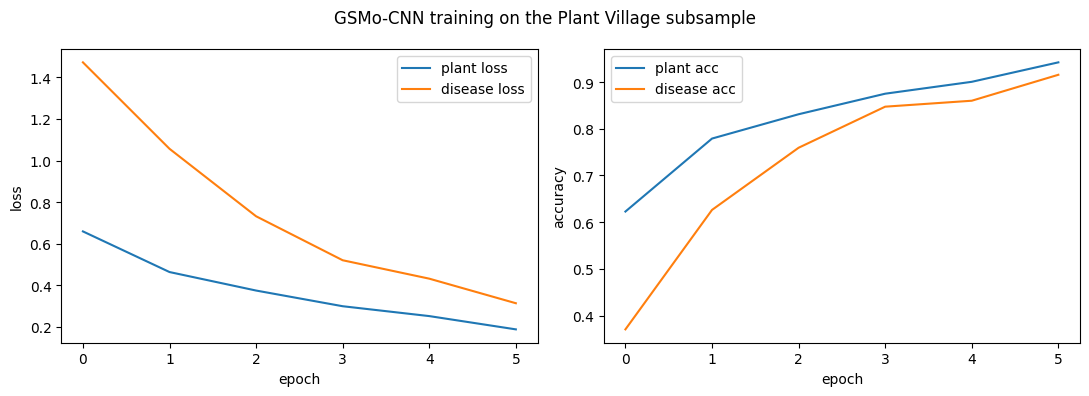

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, key in [("plant", "plant_output"), ("disease", "disease_output")]:
    axes[0].plot(history.history[key + "_loss"], label=f"{name} loss")
    axes[1].plot(history.history[key + "_accuracy"], label=f"{name} acc")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend()
fig.suptitle("GSMo-CNN training on the Plant Village subsample")
fig.tight_layout()
plt.savefig("/content/training_curves.png", dpi=100)
plt.show()

## 10. Evaluate: plant, disease and joint metrics

**Expected result:** accuracy and weighted F1 for each task on the held-out 20% test split, plus the **joint** accuracy/F1 (a prediction counts as correct only if both plant and disease match) — the paper's Section 4.3 criterion. Values come from this small single run and will differ from the paper's 10-run full-dataset means.
**期待される結果:** テスト分割における植物・病害それぞれの精度と重み付きF1、および両方が正しい場合のみ正解とする** joint（同時）**指標（論文4.3節の基準）を表示します。小規模1回の実行のため、論文の10回平均とは数値が異なります。

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import pandas as pd

pred_plant, pred_dis, _, _ = model.predict(testX, verbose=0)
y_plant_true = np.argmax(testPlantY, axis=1)
y_dis_true = np.argmax(testDiseaseY, axis=1)
y_plant_pred, y_dis_pred = np.argmax(pred_plant, axis=1), np.argmax(pred_dis, axis=1)

# joint correctness: the paper's Section 4.3 criterion (both tasks correct)
joint_ok = (y_plant_pred == y_plant_true) & (y_dis_pred == y_dis_true)

results = pd.DataFrame([
    {"task": "plant", "accuracy": accuracy_score(y_plant_true, y_plant_pred),
     "f1_weighted": f1_score(y_plant_true, y_plant_pred, average="weighted")},
    {"task": "disease", "accuracy": accuracy_score(y_dis_true, y_dis_pred),
     "f1_weighted": f1_score(y_dis_true, y_dis_pred, average="weighted")},
    # joint F1 is not class-defined in the paper; we report the paper's joint accuracy
    {"task": "joint (plant AND disease)", "accuracy": joint_ok.mean(), "f1_weighted": None},
])
results.to_csv("/content/gsmo_cnn_demo_results.csv", index=False)
print(results.to_string(index=False))
print("For reference, the paper reports (full dataset, 10 runs): disease acc 99.466% / F1 0.994466 on Plant Village with InceptionV3 — not comparable to this 6-class, 6-epoch, custom-CNN demo.")

                     task  accuracy  f1_weighted
                    plant  0.941667     0.941764
                  disease  0.833333     0.827192
joint (plant AND disease)  0.795833          NaN
For reference, the paper reports (full dataset, 10 runs): disease acc 99.466% / F1 0.994466 on Plant Village with InceptionV3 — not comparable to this 6-class, 6-epoch, custom-CNN demo.


## 11. Confusion summary

**Expected result:** the disease-confusion counts on the test split, showing which of the 3 disease classes are confused. Rendered from this run's predictions.
**期待される結果:** テスト分割における病害クラスの混同行列を表示します。

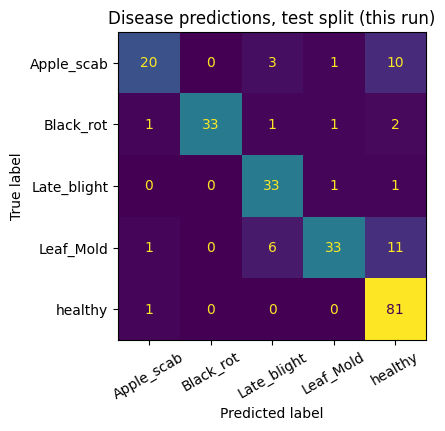

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_dis_true, y_dis_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=diseaseLB.classes_)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, xticks_rotation=30, colorbar=False)
ax.set_title("Disease predictions, test split (this run)")
plt.savefig("/content/disease_confusion.png", dpi=100, bbox_inches="tight")
plt.show()

## 12. Interpretation and limitations

- This notebook executed the **authors' own GSMo-CNN architecture and training recipe** (pinned commit `b5cee5b`) on a **deliberately tiny slice** of Plant Village: 6 classes, ≤200 images/class, 6 epochs, 1 run.
- **What is faithful:** data convention (`Plant___Disease`), 256×256 inputs, 80/20 split with `random_state=50`, LabelBinarizer, the custom CNN backbone, the four-head stacked cross-connected architecture, balance weights `[0.1, 0.1, 0.4, 0.5]`, Adamax lr 0.001, batch 16.
- **What is adapted:** subsampling, epoch count, and single-run evaluation (paper: all 38 classes, patience-50 early stopping, 10 repeated runs with mean ± std). Do **not** compare the numbers here with the published tables.
- 論文の「データ規約・分割・アーキテクチャ・損失重み・最適化手法」は著者どおりです。サブサンプリング・エポック数・1回実行のみデモ用の変更であり、数値を論文の表と比較してはいけません。
- Sources: ACM CSUR 56(6) 2024 DOI 10.1145/3639816 (ACM page returned HTTP 403 to the investigation; arXiv:2310.16273v1 used as text basis); code github.com/funzi-son/AI4Plant; data Mendeley tywbtsjrjv v1 (sha256-verified). No license file accompanies the code repository.